In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual layouts
%matplotlib inline
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_csv('Telco-Customer-Churn.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values per column after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column after conversion:
TotalCharges    11
dtype: int64


In [24]:
df.dropna(inplace=True)

# Drop Customer ID column (adjust the string casing if your columns use lowercase)
id_col = [col for col in df.columns if col.lower() == 'customerid'][0]
df.drop(columns=[id_col], inplace=True)
print(f"Cleaned Dataset Shape: {df.shape}")

Cleaned Dataset Shape: (7032, 20)


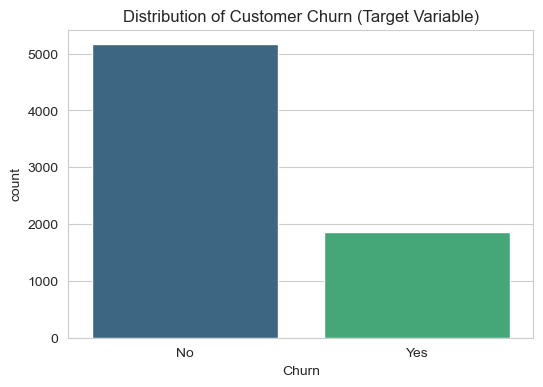

Percentage Distribution:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [25]:
#Exploratory Data Analysis (EDA)
plt.figure(figsize=(6,4))
churn_col = [col for col in df.columns if col.lower() == 'churn'][0]

sns.countplot(data=df, x=churn_col, palette='viridis')
plt.title('Distribution of Customer Churn (Target Variable)')
plt.show()

print("Percentage Distribution:")
print(df[churn_col].value_counts(normalize=True) * 100)

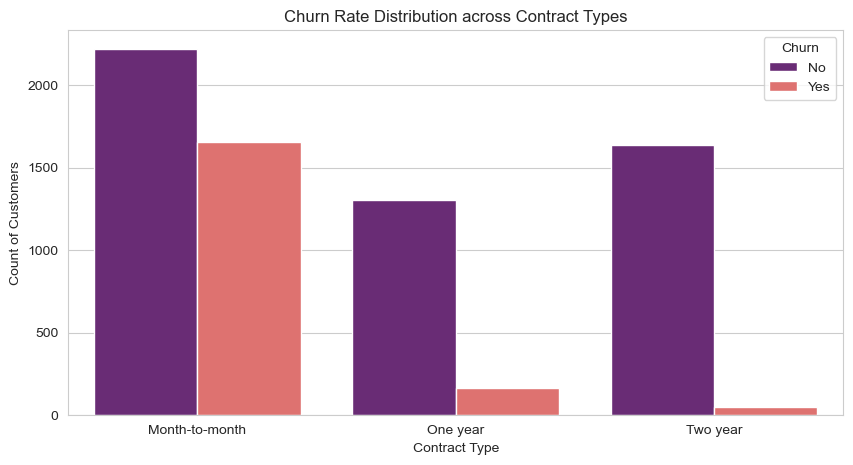

In [26]:
#Visualizing Contract Types vs. Churn
contract_col = [col for col in df.columns if col.lower() == 'contract'][0]

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x=contract_col, hue=churn_col, palette='magma')
plt.title('Churn Rate Distribution across Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Count of Customers')
plt.show()

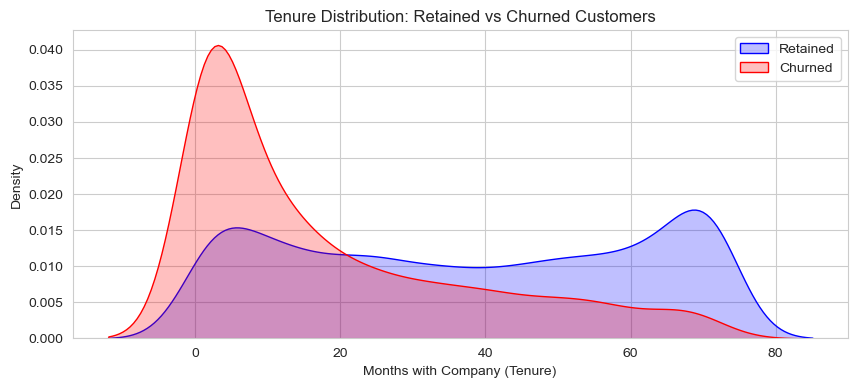

In [27]:
#Evaluating Customer Tenure
tenure_col = [col for col in df.columns if col.lower() == 'tenure'][0]

plt.figure(figsize=(10,4))
sns.kdeplot(df[df[churn_col] == 'No'][tenure_col], shade=True, color="blue", label="Retained")
sns.kdeplot(df[df[churn_col] == 'Yes'][tenure_col], shade=True, color="red", label="Churned")
plt.title('Tenure Distribution: Retained vs Churned Customers')
plt.xlabel('Months with Company (Tenure)')
plt.legend()
plt.show()

In [28]:
#Data Preprocessing
processed_df = df.copy()

churn_col = [col for col in df.columns if col.lower() == 'churn'][0]
processed_df[churn_col] = processed_df[churn_col].map({'Yes': 1, 'No': 0})

categorical_cols = processed_df.select_dtypes(include=['object']).columns.tolist()

processed_df = pd.get_dummies(processed_df, columns=categorical_cols, drop_first=True)

print(f"Encoded Dataset Shape: {processed_df.shape}")
processed_df.head()

Encoded Dataset Shape: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [29]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X = processed_df.drop(columns=[churn_col])
y = processed_df[churn_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")


Training set: (5625, 30)
Testing set: (1407, 30)


In [30]:
# Training the Supervised ML Model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Model Training Complete!")


Model Training Complete!


In [31]:
#Model Performance Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

auc_score = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {auc_score:.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1033
           1       0.55      0.75      0.64       374

    accuracy                           0.77      1407
   macro avg       0.72      0.77      0.74      1407
weighted avg       0.80      0.77      0.78      1407

--- Confusion Matrix ---
[[805 228]
 [ 93 281]]

ROC-AUC Score: 0.8361


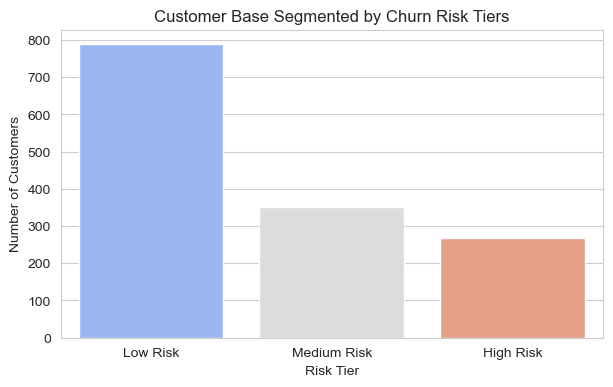


Customer Count per Risk Tier:
Risk_Tier
Low Risk       788
Medium Risk    350
High Risk      269
Name: count, dtype: int64


In [32]:
#Churn Risk Analysis
risk_df = pd.DataFrame({
    'Actual': y_test.values,
    'Probability': y_prob
})

def get_risk_tier(p):
    if p >= 0.7: return 'High Risk'
    elif p >= 0.4: return 'Medium Risk'
    else: return 'Low Risk'

risk_df['Risk_Tier'] = risk_df['Probability'].apply(get_risk_tier)

plt.figure(figsize=(7, 4))
sns.countplot(data=risk_df, x='Risk_Tier', order=['Low Risk', 'Medium Risk', 'High Risk'], palette='coolwarm')
plt.title('Customer Base Segmented by Churn Risk Tiers')
plt.xlabel('Risk Tier')
plt.ylabel('Number of Customers')
plt.show()

print("\nCustomer Count per Risk Tier:")
print(risk_df['Risk_Tier'].value_counts())

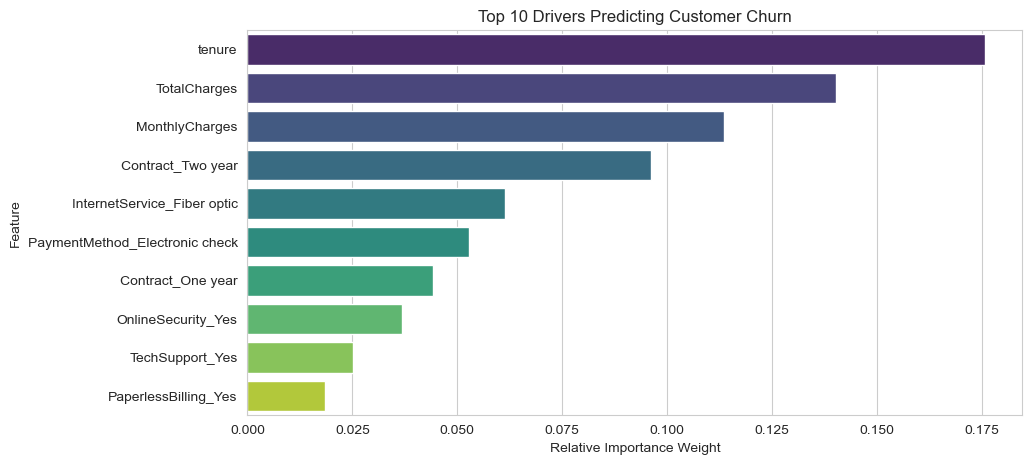

In [33]:
#Feature Importance
importances = rf_model.feature_importances_
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
features_df = features_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=features_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Drivers Predicting Customer Churn')
plt.xlabel('Relative Importance Weight')
plt.show()
